# Explore here

In [11]:
# Your code here
import pandas as pd 

In [12]:
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv')
df 


,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0
...,...,...,...
886,com.rovio.angrybirds,loved it i loooooooooooooovvved it because it...,1
887,com.rovio.angrybirds,all time legendary game the birthday party le...,1
888,com.rovio.angrybirds,ads are way to heavy listen to the bad review...,0
889,com.rovio.angrybirds,fun works perfectly well. ads aren't as annoy...,1


In [18]:

package_name = pd.unique(df['package_name'])
print(df['package_name'].value_counts())

package_name
com.facebook.katana           40
com.linkedin.android          40
com.king.candycrushsaga       40
com.imangi.templerun2         40
com.supercell.clashofclans    40
com.viber.voip                40
com.facebook.orca             40
com.Slack                     40
com.dropbox.android           40
com.evernote                  40
com.uc.browser.en             40
com.opera.mini.native         40
org.mozilla.firefox           40
com.twitter.android           39
com.android.chrome            39
com.tencent.mm                39
com.google.android.talk       39
com.whatsapp                  39
com.hamrokeyboard             39
com.rovio.angrybirds          39
com.hamropatro                38
com.shirantech.kantipur       36
jabanaki.todo.todoly          24
Name: count, dtype: int64


In [20]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

x = df["review"]
y = df["polarity"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

x_train.head()

331      just did the latest update on viber and yet ...
733     keeps crashing it only works well in extreme ...
382     the fail boat has arrived the 6.0 version is ...
704     superfast, just as i remember it ! opera mini...
813     installed and immediately deleted this crap i...
Name: review, dtype: str

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

vec_model = CountVectorizer(stop_words = "english")
x_train = vec_model.fit_transform(x_train).toarray()
x_test = vec_model.transform(x_test).toarray()
x_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(712, 3310))

In [23]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(x_train , y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [24]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0])

In [25]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test , y_pred)

0.8156424581005587

In [ ]:
from sklearn.naive_bayes import GaussianNB , BernoulliNB

model_gauss = GaussianNB ()
model_bernoulli = BernoulliNB ()

model_gauss.fit(x_train , y_train)
model_bernoulli.fit(x_train , y_train)

y_pred_gauss = model_gauss.predict(x_test)
y_pred_bernoulli = model_bernoulli.predict(x_test)

print(f'La precisión del modelo GaussianNB es de: {accuracy_score(y_test , y_pred_gauss)}')
print(f'La precisión del modelo BernoulloNB es de: {accuracy_score(y_test , y_pred_bernoulli)}')

La precisión del modelo GaussianNB es de: 0.8044692737430168
La precisión del modelo BernoulloNB es de: 0.770949720670391


In [32]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state = 42)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
y_pred_rf = model.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_rf

0.7988826815642458

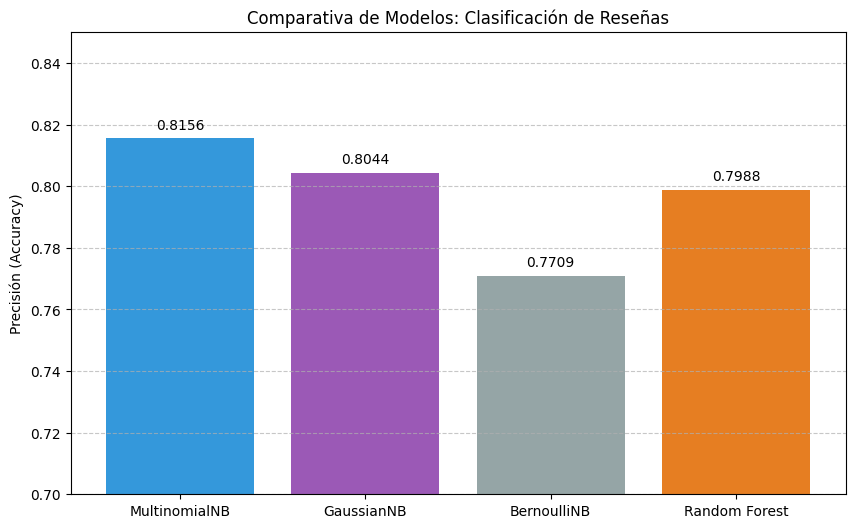

In [35]:
import matplotlib.pyplot as plt

modelos = ['MultinomialNB', 'GaussianNB', 'BernoulliNB', 'Random Forest']
precisiones = [0.8156, 0.8044, 0.7709, 0.7988] 

plt.figure(figsize=(10, 6))
barras = plt.bar(modelos, precisiones, color=['#3498db', '#9b59b6', '#95a5a6', '#e67e22'])

plt.ylim(0.7, 0.85) 
plt.ylabel('Precisión (Accuracy)')
plt.title('Comparativa de Modelos: Clasificación de Reseñas')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.002, round(yval, 4), ha='center', va='bottom')

plt.show()

### Conclusión

Tras evaluar los cuatro algoritmos de clasificación, se concluye que el modelo Multinomial Naive Bayes resultó ser el más efectivo para este dataset de texto con una precisión del 81.56%, superando incluso al Random Forest (79.88%) y a las variantes de Gaussian (80.44%) y Bernoulli (77.09%). Esto demuestra que, para tareas de procesamiento de lenguaje natural con conteo de frecuencias, un modelo probabilístico simple puede ser más robusto que uno de ensamble, especialmente cuando este último está limitado por parámetros de profundidad.